# Hierarchical clustering: the basics

**Hierarchical clustering** finds groups in data. It works in three simple steps:

1. Start with every point in a **group of its own**.
2. Find the **two closest groups** and join them.
3. **Repeat** until everything is in one big group.

Then we draw the joins as a tree, and **cut** the tree to choose how many groups we want.

We will use just **6 points**, called A to F, so you can follow every step. Run each cell in order with **Shift + Enter**.

## Step 1: Setting up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

## Step 2: Our six points

In [2]:
names = ["A", "B", "C", "D", "E", "F"]
points = np.array([[1.0, 1.0],
                   [1.7, 1.2],
                   [1.3, 2.4],
                   [5.0, 4.0],
                   [5.6, 4.5],
                   [4.6, 5.6]])

pd.DataFrame(points, index=names, columns=["x", "y"])

,x,y
A,1.0,1.0
B,1.7,1.2
C,1.3,2.4
D,5.0,4.0
E,5.6,4.5
F,4.6,5.6


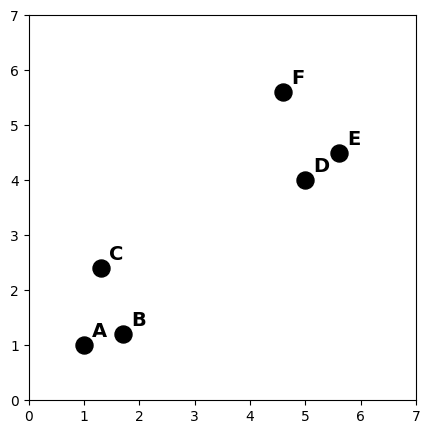

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], s=150, color="black")
for name, (x, y) in zip(names, points):
    plt.text(x + 0.15, y + 0.15, name, fontsize=14, fontweight="bold")
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.show()

By eye, there seem to be two groups: **A, B, C** in the bottom left and **D, E, F** in the top right. Let's see if the method agrees.

## Step 3: How far apart is every pair?

To find the closest points, we measure the straight-line distance between every pair.

In [4]:
distances = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        distances[i, j] = np.sqrt(((points[i] - points[j]) ** 2).sum())

pd.DataFrame(distances, index=names, columns=names).round(2)

,A,B,C,D,E,F
A,0.00,0.73,1.43,5.00,5.78,5.84
B,0.73,0.00,1.26,4.33,5.11,5.27
C,1.43,1.26,0.00,4.03,4.79,4.60
D,5.00,4.33,4.03,0.00,0.78,1.65
E,5.78,5.11,4.79,0.78,0.00,1.49
F,5.84,5.27,4.60,1.65,1.49,0.00


Read the table like a mileage chart: the row is one point, the column is the other. The 0s down the middle are each point's distance to itself.

The smallest number (apart from the 0s) is **0.73**, between **A and B**. So A and B will be joined first.

## Step 4: Join, join, join

SciPy's `linkage` function does all the joining for us. We use `"single"`, which means the distance between two groups is the distance between their **closest pair of points**.

The code below just prints each join in plain English. You do not need to understand every line.

In [5]:
joins = linkage(points, method="single")

groups = {i: names[i] for i in range(6)}      # each point starts as its own group
for step, (a, b, dist, size) in enumerate(joins, start=1):
    new_group = "".join(sorted(groups[int(a)] + groups[int(b)]))
    print(f"Step {step}: join {groups[int(a)]:>3} + {groups[int(b)]:<3}  at distance {dist:.2f}")
    groups[6 + step - 1] = new_group

Step 1: join   A + B    at distance 0.73
Step 2: join   D + E    at distance 0.78
Step 3: join   C + AB   at distance 1.26
Step 4: join   F + DE   at distance 1.49
Step 5: join ABC + DEF  at distance 4.03


Six points need **five joins** to end up as one group:

- A and B join first, then D and E.
- C joins AB, and F joins DE.
- Finally the two big groups join, at a much bigger distance (**4.03**). That big jump is a clue that they really are two separate groups.

## Step 5: Draw the tree (a dendrogram)

A **dendrogram** shows every join as a tree.

- Each point is a **leaf** at the bottom.
- Each flat bar is a **join**.
- The **height** of the bar is the distance at which the groups joined.

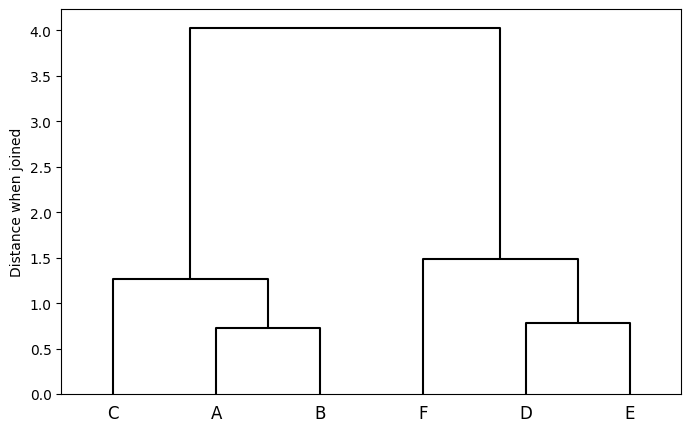

In [6]:
plt.figure(figsize=(8, 5))
dendrogram(joins, labels=names, color_threshold=0, above_threshold_color="black")
plt.ylabel("Distance when joined")
plt.show()

## Step 6: Cut the tree to get groups

Draw a horizontal line across the tree. The number of vertical lines it crosses is the **number of groups**.

A good place to cut is across the **tallest gap**, where nothing joins for a long way. Here that is between about 1.5 and 4.

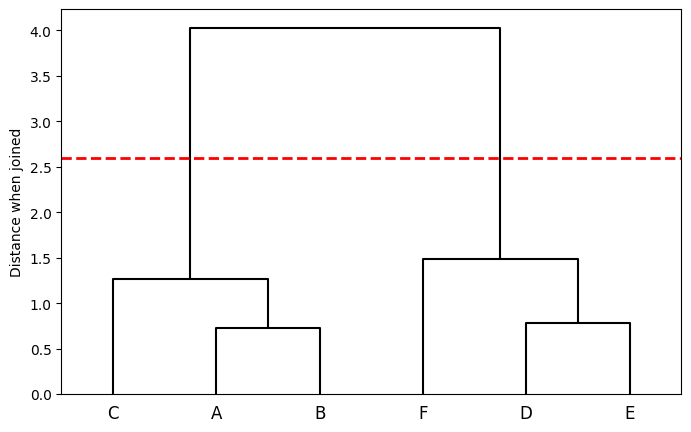

Group 1: A, B, C
Group 2: D, E, F


In [7]:
cut_height = 2.6

plt.figure(figsize=(8, 5))
dendrogram(joins, labels=names, color_threshold=0, above_threshold_color="black")
plt.axhline(cut_height, color="red", linestyle="--", linewidth=2)
plt.ylabel("Distance when joined")
plt.show()

labels = fcluster(joins, t=cut_height, criterion="distance")
for group in sorted(set(labels)):
    members = [n for n, l in zip(names, labels) if l == group]
    print(f"Group {group}: {', '.join(members)}")

Cutting at 2.6 gives **two groups**: A, B, C and D, E, F. That matches what we saw by eye.

Let's colour the points by their group.

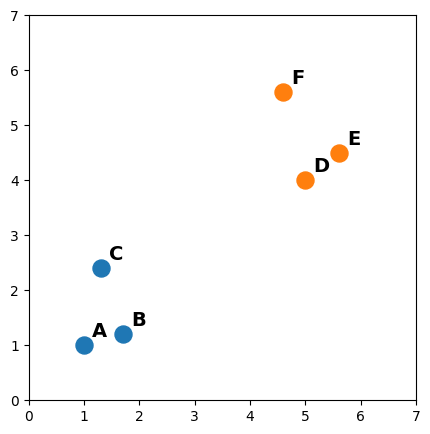

In [8]:
colours = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}

plt.figure(figsize=(5, 5))
for name, (x, y), l in zip(names, points, labels):
    plt.scatter(x, y, s=150, color=colours[l])
    plt.text(x + 0.15, y + 0.15, name, fontsize=14, fontweight="bold")
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.show()

## Step 7: The same thing in scikit-learn

In scikit-learn, hierarchical clustering is called `AgglomerativeClustering` ("agglomerate" means to gather together). Here we just ask for 2 groups.

In [9]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=2, linkage="single")
result = model.fit_predict(points)

for name, group in zip(names, result):
    print(name, "-> group", group)

A -> group 1
B -> group 1
C -> group 1
D -> group 0
E -> group 0
F -> group 0


Same two groups. The numbers 0 and 1 are just names for the groups; which group gets which number does not matter.

## Summary

| Idea | What it means |
|---|---|
| Start | Every point is its own group |
| Join | Keep joining the two closest groups |
| Dendrogram | A tree of the joins. Bar height = distance |
| Cut | A horizontal line across the tree. Lines crossed = number of groups |
| Big jump | A tall gap in the tree means the groups really are separate |

Unlike k-means, you do **not** have to choose the number of groups before you start. You build the tree first, then decide where to cut.

## Things to try

1. In Step 6, change `cut_height` to **1.37**. How many groups do you get now, and which points are in each?
2. In Step 2, add a seventh point **G** at `[3.0, 3.0]` (and add `"G"` to `names`). Run everything again. Where does G join the tree?
3. In Step 4, change `"single"` to `"complete"` (the distance between the **furthest** pair of points). Do the join distances change? Does the tree change shape?

In [10]:
# Your experiments here